In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('/content/global_earthquakes_2020_2026.csv')

In [3]:
df.head()

,id,time,year,decade,latitude,longitude,depth,mag,magType,place,...,mag_category,nst,gap,dmin,rms,horizontalError,depthError,magError,status,net
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",...,5.0-5.5,NaN,74.0,1.190,0.79,9.4,6.3,0.044,reviewed,us
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",...,NaN,NaN,94.0,0.496,0.66,7.7,4.6,0.026,reviewed,us
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",...,5.0-5.5,NaN,40.0,2.947,1.44,8.8,1.8,0.086,reviewed,us
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,...,NaN,NaN,105.0,19.424,0.83,14.0,1.9,0.082,reviewed,us
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",...,NaN,NaN,117.0,0.392,0.72,5.0,2.5,0.038,reviewed,us


In [4]:
df.shape

(11808, 21)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
id,0
time,0
year,0
decade,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
place,0


In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_762/2734919179.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
print(df.isna().sum().sum())

0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11808 non-null  object 
 1   time             11808 non-null  object 
 2   year             11808 non-null  int64  
 3   decade           11808 non-null  int64  
 4   latitude         11808 non-null  float64
 5   longitude        11808 non-null  float64
 6   depth            11808 non-null  float64
 7   mag              11808 non-null  float64
 8   magType          11808 non-null  object 
 9   place            11808 non-null  object 
 10  region           11808 non-null  object 
 11  mag_category     11808 non-null  object 
 12  nst              11808 non-null  float64
 13  gap              11808 non-null  float64
 14  dmin             11808 non-null  float64
 15  rms              11808 non-null  float64
 16  horizontalError  11808 non-null  float64
 17  depthError  

In [10]:
df.dtypes

,0
id,object
time,object
year,int64
decade,int64
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
place,object


In [11]:
df['status'].value_counts()

,count
status,
reviewed,11808


In [12]:
df['status'].nunique()

1

In [13]:
df['status'].unique()

array(['reviewed'], dtype=object)

In [14]:
df.drop(columns=['status'], inplace=True)

In [15]:
df['id'].value_counts()

,count
id,
us7000szvv,1
us7000szvq,1
us7000szuz,1
us7000szu6,1
us7000szri,1
...,...
us70006t6h,1
us70006t6a,1
us70006t3c,1


In [16]:
df['id'].nunique()

11808

In [17]:
df['id'].nunique() == len(df)

True

In [18]:
df.drop(columns=['id'], inplace=True)

In [19]:
df['time'].value_counts()

,count
time,
2026-07-12 13:46:37.185000+00:00,1
2026-07-12 13:20:25.867000+00:00,1
2026-07-12 11:09:45.067000+00:00,1
2026-07-12 07:29:23.556000+00:00,1
2026-07-11 17:49:31.928000+00:00,1
...,...
2020-01-01 16:51:32.285000+00:00,1
2020-01-01 16:34:59.178000+00:00,1
2020-01-01 08:31:24.136000+00:00,1


In [20]:
df['time'].nunique()

11808

In [21]:
df['time'].nunique() == len(df)

True

In [22]:
df.drop(columns=['time'], inplace=True)

In [23]:
df['magType'].value_counts()

,count
magType,
mww,7124
mb,4467
mwr,64
mw,59
ml,51
mwb,33
mwp,7
mwc,2
ml(texnet),1


In [24]:
df['magType'].nunique()

9

In [25]:
df['place'].value_counts()

,count
place,
South Sandwich Islands region,706
Kermadec Islands region,372
southeast of the Loyalty Islands,246
"Kermadec Islands, New Zealand",163
south of the Fiji Islands,139
...,...
"149 km NW of Ternate, Indonesia",1
"98 km SSW of Ishigaki, Japan",1
"210 km SW of Merizo Village, Guam",1


In [26]:
df['place'].nunique()

7322

In [27]:
place_freq = df['place'].value_counts()
df['place_freq'] = df['place'].map(place_freq).fillna(0).astype('int64')

In [28]:
df.drop(columns=['place'], inplace=True)

In [29]:
df['region'].value_counts()

,count
region,
Indonesia,1025
Russia,747
South Sandwich Islands region,706
Philippines,652
Papua New Guinea,607
...,...
Saudi Arabia,1
Southern Drake Passage Earthquake,1
Hubbard Glacier Earthquake,1


In [30]:
df['region'].nunique()

296

In [31]:
region_freq = df['region'].value_counts()
df['region_freq'] = df['region'].map(region_freq).fillna(0).astype('int64')

In [32]:
df.drop(columns=['region'], inplace=True)

In [33]:
df['net'].value_counts()

,count
net,
us,11642
ak,57
iscgem,31
pr,26
nc,18
nn,10
ci,8
tx,7
hv,6


In [34]:
df['net'].nunique()

12

In [35]:
df = pd.get_dummies(df, columns=['magType', 'net'], dtype='int64', drop_first=True)

In [36]:
df['mag_category'].value_counts()

,count
mag_category,
5.0-5.5,9426
5.5-6.0,1700
6.0-6.5,461
6.5-7.0,152
7.0+,69


In [37]:
df['mag_category'].nunique()

5

In [38]:
mapping = {
    '5.0-5.5': 0,
    '5.5-6.0': 1,
    '6.0-6.5': 2,
    '6.5-7.0': 3,
    '7.0+': 4
}

df['mag_category'] = df['mag_category'].map(mapping)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                11808 non-null  int64  
 1   decade              11808 non-null  int64  
 2   latitude            11808 non-null  float64
 3   longitude           11808 non-null  float64
 4   depth               11808 non-null  float64
 5   mag                 11808 non-null  float64
 6   mag_category        11808 non-null  int64  
 7   nst                 11808 non-null  float64
 8   gap                 11808 non-null  float64
 9   dmin                11808 non-null  float64
 10  rms                 11808 non-null  float64
 11  horizontalError     11808 non-null  float64
 12  depthError          11808 non-null  float64
 13  magError            11808 non-null  float64
 14  place_freq          11808 non-null  int64  
 15  region_freq         11808 non-null  int64  
 16  magT

In [40]:
print(df['mag_category'].skew(),
      df['mag_category'].describe())

2.81213462011989 count    11808.000000
mean         0.284045
std          0.654859
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: mag_category, dtype: float64


In [41]:
X = df.drop(columns=['mag_category', 'mag'])
y = df['mag_category']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape,
      X_test.shape,
      y_train.shape,
      y_test.shape)

(9446, 33) (2362, 33) (9446,) (2362,)


In [44]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [45]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [46]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [47]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([1.00960669e+00, 0.00000000e+00, 9.98002825e-01, 9.93814406e-01,
       1.05884605e+00, 1.02778231e+00, 1.00438415e+00, 1.09349084e+00,
       1.02426889e+00, 9.96545130e-01, 1.14361764e+00, 1.01232987e+00,
       9.89070174e-01, 9.93898433e-01, 9.26017749e-01, 1.73472348e-18,
       1.27052430e+00, 7.43215331e-01, 3.46944695e-18, 3.46944695e-18,
       8.09772458e-01, 9.98159022e-01, 1.54845520e+00, 3.46944695e-18,
       1.17884785e+00, 1.41316462e+00, 1.30882214e+00, 0.00000000e+00,
       7.22660192e-01, 0.00000000e+00, 3.46944695e-18, 1.01471461e+00,
       1.73472348e-18])

In [48]:
correlation = df.corr(numeric_only=True)['mag_category'].sort_values(ascending=False)
print(correlation)

mag_category          1.000000
mag                   0.919560
magType_mww           0.289336
nst                   0.266857
depth                 0.093807
magType_mwb           0.055431
rms                   0.039042
magType_mwc           0.024169
net_nc                0.022831
net_hv                0.013175
latitude              0.010740
net_uu                0.010062
net_pr                0.009974
magType_mwp           0.005375
net_nn                0.005155
magType_ml            0.001013
magType_mw            0.000443
net_ci               -0.001354
net_se               -0.003992
magType_ml(texnet)   -0.003992
net_ok               -0.003992
net_us               -0.006425
longitude            -0.007157
year                 -0.010115
net_tx               -0.010564
magType_mwr          -0.019691
net_iscgem           -0.022255
region_freq          -0.035548
dmin                 -0.038158
place_freq           -0.052916
horizontalError      -0.105505
depthError           -0.145988
magError

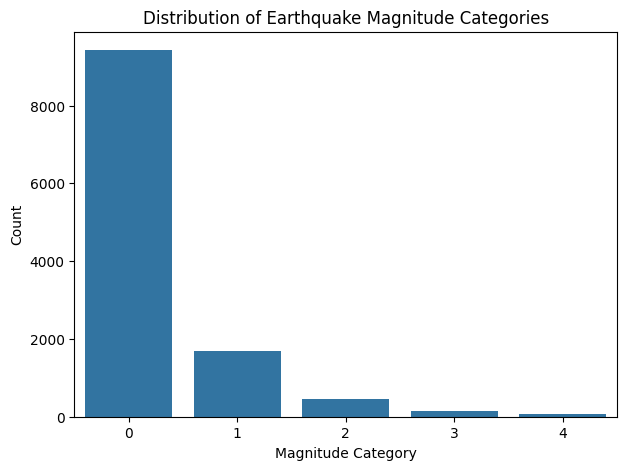

In [49]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='mag_category')

plt.title("Distribution of Earthquake Magnitude Categories")
plt.xlabel("Magnitude Category")
plt.ylabel("Count")
plt.show()

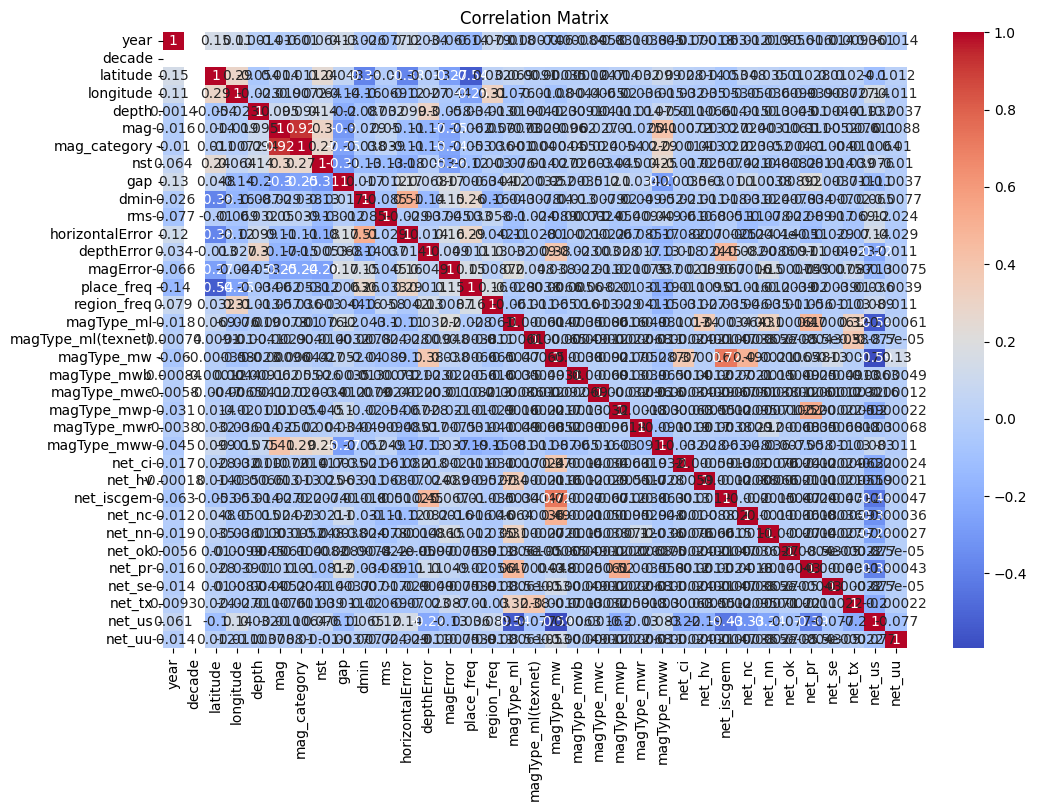

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

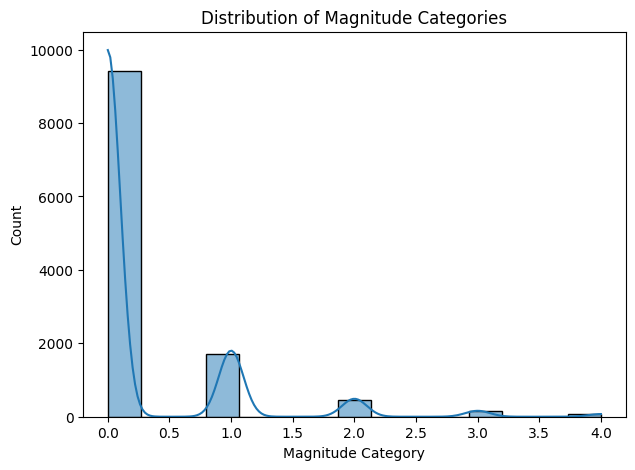

In [51]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x='mag_category',
    kde=True
)

plt.title("Distribution of Magnitude Categories")
plt.xlabel("Magnitude Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_762/3912787468.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['mag_category'], kde=True)


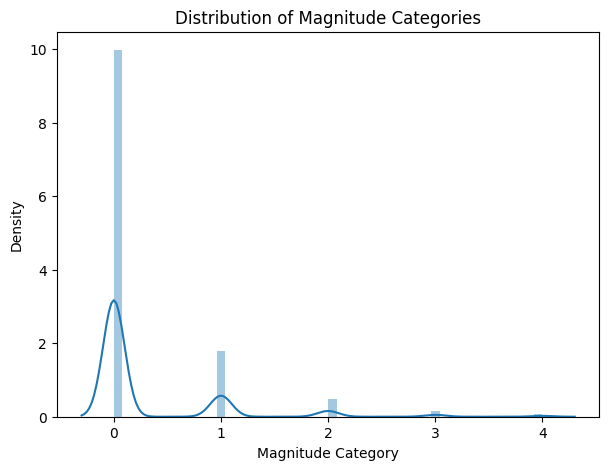

In [52]:
plt.figure(figsize=(7,5))

sns.distplot(df['mag_category'], kde=True)

plt.title("Distribution of Magnitude Categories")
plt.xlabel("Magnitude Category")
plt.show()

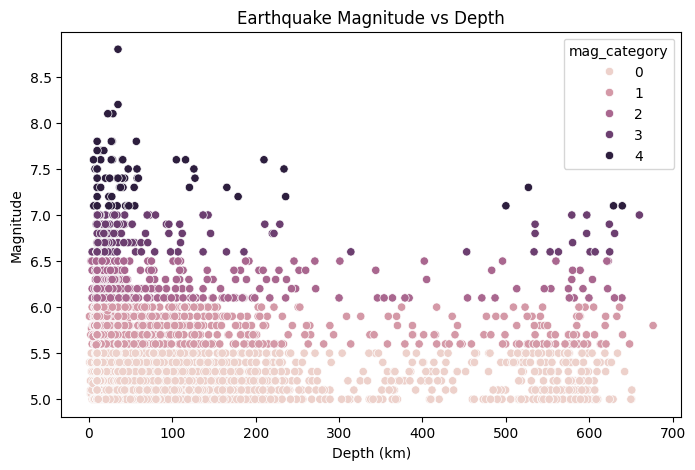

In [53]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='depth',
    y='mag',
    hue='mag_category'
)

plt.title("Earthquake Magnitude vs Depth")
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.show()

In [54]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [55]:
pred_log = model_log.predict(X_test_scaled)
pred_prob = model_log.predict_proba(X_test_scaled)

In [56]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [57]:
print(classification_report(
    y_test,
    pred_log,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.95      0.73      0.83      1886
           1       0.23      0.34      0.27       340
           2       0.23      0.28      0.25        92
           3       0.06      0.43      0.11        30
           4       0.08      0.57      0.15        14

    accuracy                           0.65      2362
   macro avg       0.31      0.47      0.32      2362
weighted avg       0.81      0.65      0.71      2362



In [58]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(confusion_matrix(y_test, pred_log))

print(classification_report(
    y_test,
    pred_log,
    zero_division=0
))

[[1377  372   34   71   32]
 [  60  114   49   83   34]
 [   3   12   26   35   16]
 [   2    4    5   13    6]
 [   0    0    1    5    8]]
              precision    recall  f1-score   support

           0       0.95      0.73      0.83      1886
           1       0.23      0.34      0.27       340
           2       0.23      0.28      0.25        92
           3       0.06      0.43      0.11        30
           4       0.08      0.57      0.15        14

    accuracy                           0.65      2362
   macro avg       0.31      0.47      0.32      2362
weighted avg       0.81      0.65      0.71      2362



In [59]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

print("Accuracy:", accuracy_score(y_test, pred_log))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_log))
print("Macro F1:", f1_score(y_test, pred_log, average="macro"))
print("Weighted F1:", f1_score(y_test, pred_log, average="weighted"))

roc_auc = roc_auc_score(
    y_test,
    pred_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC:", roc_auc)

y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

pr_auc = average_precision_score(
    y_test_bin,
    pred_prob,
    average="weighted"
)

print("PR-AUC:", pr_auc)

Accuracy: 0.6511430990685859
Balanced Accuracy: 0.47055627341074285
Macro F1: 0.32093496054317827
Weighted F1: 0.7117762315156568
ROC-AUC: 0.8429536205232047
PR-AUC: 0.800880811461


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

scores = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.82303133 0.82387807 0.83530906 0.8360864  0.83015671]
Mean Accuracy: 0.8296923152512552


In [61]:
from sklearn.model_selection import cross_val_score

# F1 Score (Weighted)
scores = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='recall_weighted'
)
print("Mean Recall (Weighted):", scores.mean())

# Balanced Accuracy
scores = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)
print("Mean Balanced Accuracy:", scores.mean())

Mean F1 (Weighted): 0.7935227467146961
Mean Recall (Weighted): 0.8296923152512552
Mean Balanced Accuracy: 0.3005869569379356


In [62]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=1000,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [63]:
model_rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=1000, n_jobs=-1,
                       random_state=42)

In [64]:
pred_rf = model_rf.predict(X_test)
pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [65]:
print(confusion_matrix(y_test, pred_rf))
print(classification_report(
    y_test,
    pred_rf,
    zero_division=0
))

[[1626  214   31   13    2]
 [ 110  149   59   19    3]
 [   7   31   43   11    0]
 [   3   12    9    6    0]
 [   1    0    8    3    2]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1886
           1       0.37      0.44      0.40       340
           2       0.29      0.47      0.36        92
           3       0.12      0.20      0.15        30
           4       0.29      0.14      0.19        14

    accuracy                           0.77      2362
   macro avg       0.40      0.42      0.40      2362
weighted avg       0.81      0.77      0.79      2362



In [66]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("F1 Weighted:", scores)
print("Mean F1 Weighted:", scores.mean())

F1 Weighted: [0.75598601 0.77664889 0.78797029 0.80263952 0.81041775]
Mean F1 Weighted: 0.7867324920487878


In [67]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Mean F1 Macro:", scores.mean())

Mean F1 Macro: 0.37927235010126903


In [68]:
from sklearn.model_selection import cross_val_score

# F1 Score (Weighted)
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='recall_weighted'
)
print("Mean Recall (Weighted):", scores.mean())

# Balanced Accuracy
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)
print("Mean Balanced Accuracy:", scores.mean())

Mean F1 (Weighted): 0.7867324920487878
Mean Recall (Weighted): 0.7727017965162798
Mean Balanced Accuracy: 0.39666752125939075


In [69]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [70]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [71]:
pred_xgb = model_xgb.predict(X_test)
pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [72]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(
    y_test,
    pred_xgb,
    zero_division=0
))


[[1839   43    3    1    0]
 [ 177  143   19    1    0]
 [  19   52   18    3    0]
 [   7   14    7    2    0]
 [   1    3    6    1    3]]
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1886
           1       0.56      0.42      0.48       340
           2       0.34      0.20      0.25        92
           3       0.25      0.07      0.11        30
           4       1.00      0.21      0.35        14

    accuracy                           0.85      2362
   macro avg       0.61      0.37      0.42      2362
weighted avg       0.82      0.85      0.83      2362



In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("F1 Weighted:", scores)
print("Mean F1 Weighted:", scores.mean())

F1 Weighted: [0.80976635 0.82323646 0.83430315 0.83569973 0.81034469]
Mean F1 Weighted: 0.8226700740644229


In [74]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1 Macro:", scores)
print("Mean F1 Macro:", scores.mean())

F1 Macro: [0.41710061 0.33905337 0.37107756 0.4449349  0.31537577]
Mean F1 Macro: 0.3775084413690357


In [75]:
from sklearn.model_selection import cross_val_score

# F1 Score (Weighted)
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='recall_weighted'
)
print("Mean Recall (Weighted):", scores.mean())

# Balanced Accuracy
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)
print("Mean Balanced Accuracy:", scores.mean())

Mean F1 (Weighted): 0.8226700740644229
Mean Recall (Weighted): 0.843496365760142
Mean Balanced Accuracy: 0.34841172007157883


In [76]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbr = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [77]:
model_gbr.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [78]:
pred_gbr = model_gbr.predict(X_test)
pred_proba_gbr = model_gbr.predict_proba(X_test)[:, 1]

In [79]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_gbr))
print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))


[[1848   34    3    1    0]
 [ 198  127   13    2    0]
 [  24   51   15    2    0]
 [   6   16    7    1    0]
 [   0    5    5    2    2]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1886
           1       0.55      0.37      0.44       340
           2       0.35      0.16      0.22        92
           3       0.12      0.03      0.05        30
           4       1.00      0.14      0.25        14

    accuracy                           0.84      2362
   macro avg       0.58      0.34      0.38      2362
weighted avg       0.81      0.84      0.82      2362



In [80]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(confusion_matrix(y_test, pred_gbr))

print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))

[[1848   34    3    1    0]
 [ 198  127   13    2    0]
 [  24   51   15    2    0]
 [   6   16    7    1    0]
 [   0    5    5    2    2]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1886
           1       0.55      0.37      0.44       340
           2       0.35      0.16      0.22        92
           3       0.12      0.03      0.05        30
           4       1.00      0.14      0.25        14

    accuracy                           0.84      2362
   macro avg       0.58      0.34      0.38      2362
weighted avg       0.81      0.84      0.82      2362



In [81]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_gbr))
print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))


[[1848   34    3    1    0]
 [ 198  127   13    2    0]
 [  24   51   15    2    0]
 [   6   16    7    1    0]
 [   0    5    5    2    2]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1886
           1       0.55      0.37      0.44       340
           2       0.35      0.16      0.22        92
           3       0.12      0.03      0.05        30
           4       1.00      0.14      0.25        14

    accuracy                           0.84      2362
   macro avg       0.58      0.34      0.38      2362
weighted avg       0.81      0.84      0.82      2362



In [83]:
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Mean F1 (Macro):", scores.mean())

Mean F1 (Macro): 0.36237830599677884


In [84]:
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("Mean F1 (Weighted):", scores.mean())

Mean F1 (Weighted): 0.8167049084740807


In [82]:
from sklearn.model_selection import cross_val_score

# F1 Score (Weighted)
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='recall_weighted'
)
print("Mean Recall (Weighted):", scores.mean())

# Balanced Accuracy
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)
print("Mean Balanced Accuracy:", scores.mean())

Mean F1 (Weighted): 0.8167049084740807
Mean Recall (Weighted): 0.8404476353501957
Mean Balanced Accuracy: 0.3361783770340187


In [85]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [86]:
pred_dt = model_dt.predict(X_test)

In [87]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_dt))

print("\nClassification Report:")
print(classification_report(
    y_test,
    pred_dt,
    zero_division=0
))

Confusion Matrix:
[[1394  279  103   60   50]
 [  81  109   61   75   14]
 [   7   21   18   45    1]
 [   2    9    4   13    2]
 [   0    2    1    6    5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83      1886
           1       0.26      0.32      0.29       340
           2       0.10      0.20      0.13        92
           3       0.07      0.43      0.11        30
           4       0.07      0.36      0.12        14

    accuracy                           0.65      2362
   macro avg       0.29      0.41      0.29      2362
weighted avg       0.79      0.65      0.71      2362



In [88]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)

print("F1 Weighted:", scores)
print("Mean F1 Weighted:", scores.mean())

F1 Weighted: [0.68938776 0.7018372  0.70183394 0.6811504  0.74120034]
Mean F1 Weighted: 0.7030819303487205


In [89]:
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Mean F1 Macro:", scores.mean())

Mean F1 Macro: 0.30136142972534824


In [90]:
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)

print("Balanced Accuracy:", scores)
print("Mean Balanced Accuracy:", scores.mean())

Balanced Accuracy: [0.44647151 0.37280496 0.40048864 0.50211437 0.4252618 ]
Mean Balanced Accuracy: 0.42942825575164534


In [91]:
from sklearn.model_selection import cross_val_score

# F1 Score (Weighted)
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='f1_weighted'
)
print("Mean F1 (Weighted):", scores.mean())

# Recall (Weighted)
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='recall_weighted'
)
print("Mean Recall (Weighted):", scores.mean())

# Balanced Accuracy
scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=5,
    scoring='balanced_accuracy'
)
print("Mean Balanced Accuracy:", scores.mean())

Mean F1 (Weighted): 0.7030819303487205
Mean Recall (Weighted): 0.6510867573227235
Mean Balanced Accuracy: 0.42942825575164534


In [92]:
import joblib

joblib.dump(model_xgb, "global_earthquake_model.pkl", compress=3)

['global_earthquake_model.pkl']

In [93]:
import joblib

loaded_model = joblib.load('global_earthquake_model.pkl')

In [94]:
print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [95]:
pred = loaded_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8488569009314141
